## PCOS Prediction Model


### 1. Importing Libraries


In [39]:
!pip install lightgbm

In [40]:
! pip install catboost

In [41]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Model selection and evaluation
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

# Standard classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Advanced ensembles & boosting
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# Feature selection and balancing
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif, f_classif, RFECV
from imblearn.over_sampling import SMOTE


### 2. Uploading & Loading the Dataset


In [42]:
df = pd.read_csv('/Users/soumyaprasad/Desktop/pcos/PCOS_data.csv')

### 3. Analysing The Data & Preprocessing


In [43]:
df.head()


,0,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
0,1,1,0,28,44.6,152.0,19.3,15,78,22,...,0,1,0,110,80,3,3,18.0,18.0,8.5
1,2,2,0,36,65.0,161.5,24.9,15,74,20,...,0,0,0,120,70,3,5,15.0,14.0,3.7
2,3,3,1,33,68.8,165.0,25.3,11,72,18,...,1,1,0,120,80,13,15,18.0,20.0,10.0
3,4,4,0,37,65.0,148.0,29.7,13,72,20,...,0,0,0,120,70,2,2,15.0,14.0,7.5
4,5,5,0,25,52.0,161.0,20.1,11,72,18,...,0,0,0,120,80,3,4,16.0,14.0,7.0


In [44]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   0                       541 non-null    int64  
 1   Patient File No.        541 non-null    int64  
 2   PCOS (Y/N)              541 non-null    int64  
 3    Age (yrs)              541 non-null    int64  
 4   Weight (Kg)             541 non-null    float64
 5   Height(Cm)              541 non-null    float64
 6   BMI                     541 non-null    float64
 7   Blood Group             541 non-null    int64  
 8   Pulse rate(bpm)         541 non-null    int64  
 9   RR (breaths/min)        541 non-null    int64  
 10  Hb(g/dl)                541 non-null    float64
 11  Cycle(R/I)              541 non-null    int64  
 12  Cycle length(days)      541 non-null    int64  
 13  Marraige Status (Yrs)   541 non-null    float64
 14  Pregnant(Y/N)           541 non-null    in

In [45]:
df.describe()


,0,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
count,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,...,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000
mean,271.000000,271.000000,0.327172,31.430684,59.637153,156.484835,24.307579,13.802218,73.247689,19.243993,...,0.489834,0.515712,0.247689,114.661738,76.927911,6.129390,6.641405,15.018115,15.451701,8.475915
std,156.317519,156.317519,0.469615,5.411006,11.028287,6.033545,4.055129,1.840812,4.430285,1.688629,...,0.500359,0.500216,0.432070,7.384556,5.574112,4.229294,4.436889,3.566839,3.318848,2.165381
min,1.000000,1.000000,0.000000,20.000000,31.000000,137.000000,12.400000,11.000000,13.000000,16.000000,...,0.000000,0.000000,0.000000,12.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,136.000000,136.000000,0.000000,28.000000,52.000000,152.000000,21.600000,13.000000,72.000000,18.000000,...,0.000000,0.000000,0.000000,110.000000,70.000000,3.000000,3.000000,13.000000,13.000000,7.000000
50%,271.000000,271.000000,0.000000,31.000000,59.000000,156.000000,24.200000,14.000000,72.000000,18.000000,...,0.000000,1.000000,0.000000,110.000000,80.000000,5.000000,6.000000,15.000000,16.000000,8.500000
75%,406.000000,406.000000,1.000000,35.000000,65.000000,160.000000,26.600000,15.000000,74.000000,20.000000,...,1.000000,1.000000,0.000000,120.000000,80.000000,9.000000,10.000000,18.000000,18.000000,9.800000
max,541.000000,541.000000,1.000000,48.000000,108.000000,180.000000,38.900000,18.000000,82.000000,28.000000,...,1.000000,1.000000,1.000000,140.000000,100.000000,22.000000,20.000000,24.000000,24.000000,18.000000


In [46]:
# Inspect object-type columns
for column in df.columns:
    if df[column].dtype == 'object':
        print(f"Column: {column}")
        print(df[column].unique())

# Convert all column types to numeric (forcing errors to NaN)
df = df.apply(pd.to_numeric, errors='coerce')

# Drop columns with NaN values (optional)
df = df.dropna(axis=1, how='any')


Column: II    beta-HCG(mIU/mL)
['1.99' '494.08' '801.45' '100.51' '158.51' '1214.23' '91.55' '749.98'
 '218.65' '13' '610.63' '4490.18' '11.24' '15' '768.03' '12' '10' '20'
 '30.66' '1455' '497.41' '167' '9.83' '141.06' '528.5' '177.57' '65.03'
 '173.66' '161.49' '3.98' '756.61' '255.02' '273.7' '14.46' '145.89'
 '100.09' '110.17' '174.37' '75.51' '3893.06' '600.23' '3350.19' '97.63'
 '14.4' '2' '177.58' '12.17' '25.3' '100.2' '479.66' '1.9' '586.06'
 '1.99.' '2.8' '15.36' '54.08' '152.13' '3.05' '201.36' '16069.69' '57.08'
 '232.71' '23.5' '180.3' '102.3' '481.3' '563.8' '4.32' '230.5' '155.3'
 '3.888' '523.6' '1.65' '3.83' '569.1' '236.5' '896.6' '2.58' '569.3'
 '108.66' '3.99' '121.8' '122.58' '355.28' '122.3' '596.2' '588.7' '147.6'
 '12.37' '144.63' '475.04' '515.53' '99.69' '70.42' '342.91' '148.52'
 '272.78' '355.51' '150.91' '391.46' '464.12' '41.77' '1390.58' '213.83'
 '45.9' '18.36' '154.48' '25000' '638.52' '4.76' '18.13' '89.34' '366.04'
 '14.34' '75.62' '4.96' '1134.4' '78

In [47]:
df.isnull().sum()


0                         0
Patient File No.          0
PCOS (Y/N)                0
 Age (yrs)                0
Weight (Kg)               0
Height(Cm)                0
BMI                       0
Blood Group               0
Pulse rate(bpm)           0
RR (breaths/min)          0
Hb(g/dl)                  0
Cycle(R/I)                0
Cycle length(days)        0
Marraige Status (Yrs)     0
Pregnant(Y/N)             0
No. of abortions          0
  I   beta-HCG(mIU/mL)    0
FSH(mIU/mL)               0
LH(mIU/mL)                0
FSH/LH                    0
Hip(inch)                 0
Waist(inch)               0
Waist:Hip Ratio           0
TSH (mIU/L)               0
PRL(ng/mL)                0
Vit D3 (ng/mL)            0
PRG(ng/mL)                0
RBS(mg/dl)                0
Weight gain(Y/N)          0
hair growth(Y/N)          0
Skin darkening (Y/N)      0
Hair loss(Y/N)            0
Pimples(Y/N)              0
Fast food (Y/N)           0
Reg.Exercise(Y/N)         0
BP _Systolic (mmHg) 

### 4. Exploratory Data Analysis & Visualizations


#### Class Distribution (Imbalance check)


/var/folders/ww/kfyfht1d7qzgzyfc6g12qw800000gn/T/ipykernel_25837/2618145347.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="Blues_d")


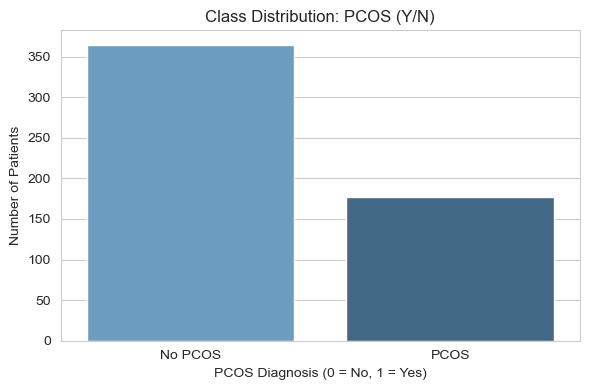

In [48]:
target_column = 'PCOS (Y/N)'
class_counts = df[target_column].value_counts()

# Plot the class imbalance
plt.figure(figsize=(6, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="Blues_d")
plt.title("Class Distribution: PCOS (Y/N)")
plt.xlabel("PCOS Diagnosis (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")
plt.xticks([0, 1], ['No PCOS', 'PCOS'])
plt.tight_layout()
plt.show()


#### Patient Demographics Distribution


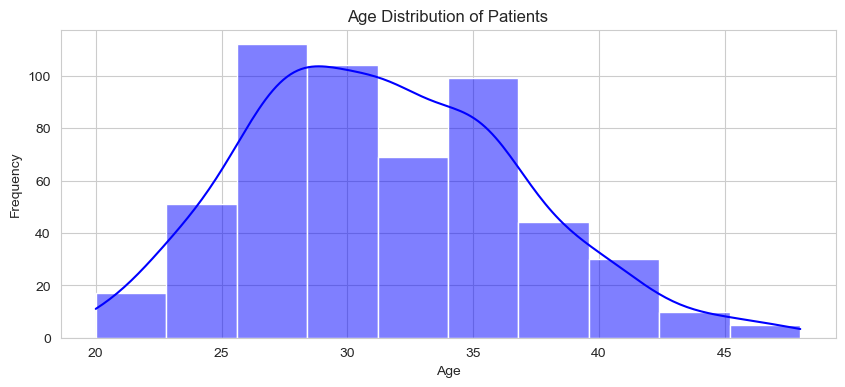

In [49]:
sns.set_style('whitegrid')

# Age Distribution
plt.figure(figsize=(10, 4))
sns.histplot(df[' Age (yrs)'], kde=True, color = 'blue', bins = 10)
plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


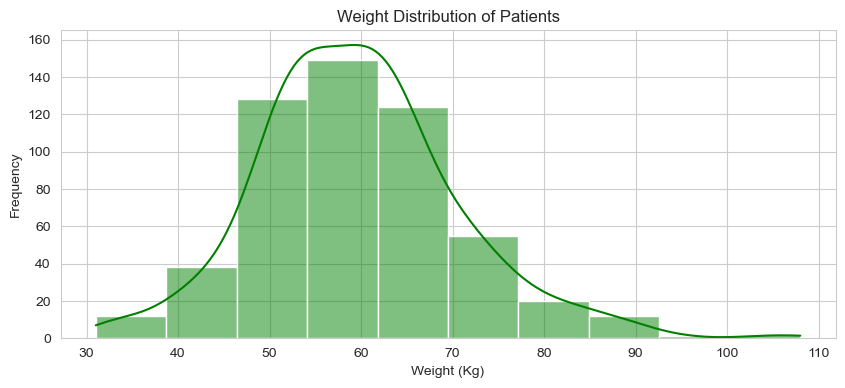

In [50]:
# Weight Distribution
plt.figure(figsize=(10, 4))
sns.histplot(df['Weight (Kg)'], kde=True, color = 'green', bins = 10)
plt.title('Weight Distribution of Patients')
plt.xlabel('Weight (Kg)')
plt.ylabel('Frequency')
plt.show()


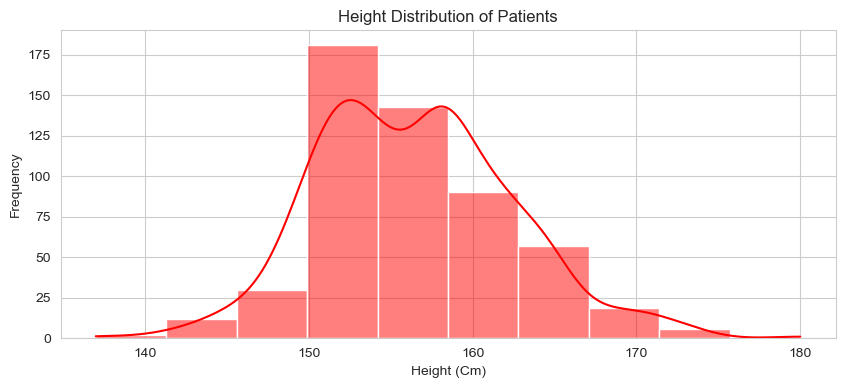

In [51]:
# Height Distribution
plt.figure(figsize=(10, 4))
sns.histplot(df['Height(Cm) '], kde=True, color = 'red', bins = 10)
plt.title('Height Distribution of Patients')
plt.xlabel('Height (Cm)')
plt.ylabel('Frequency')
plt.show()


#### Feature Correlations


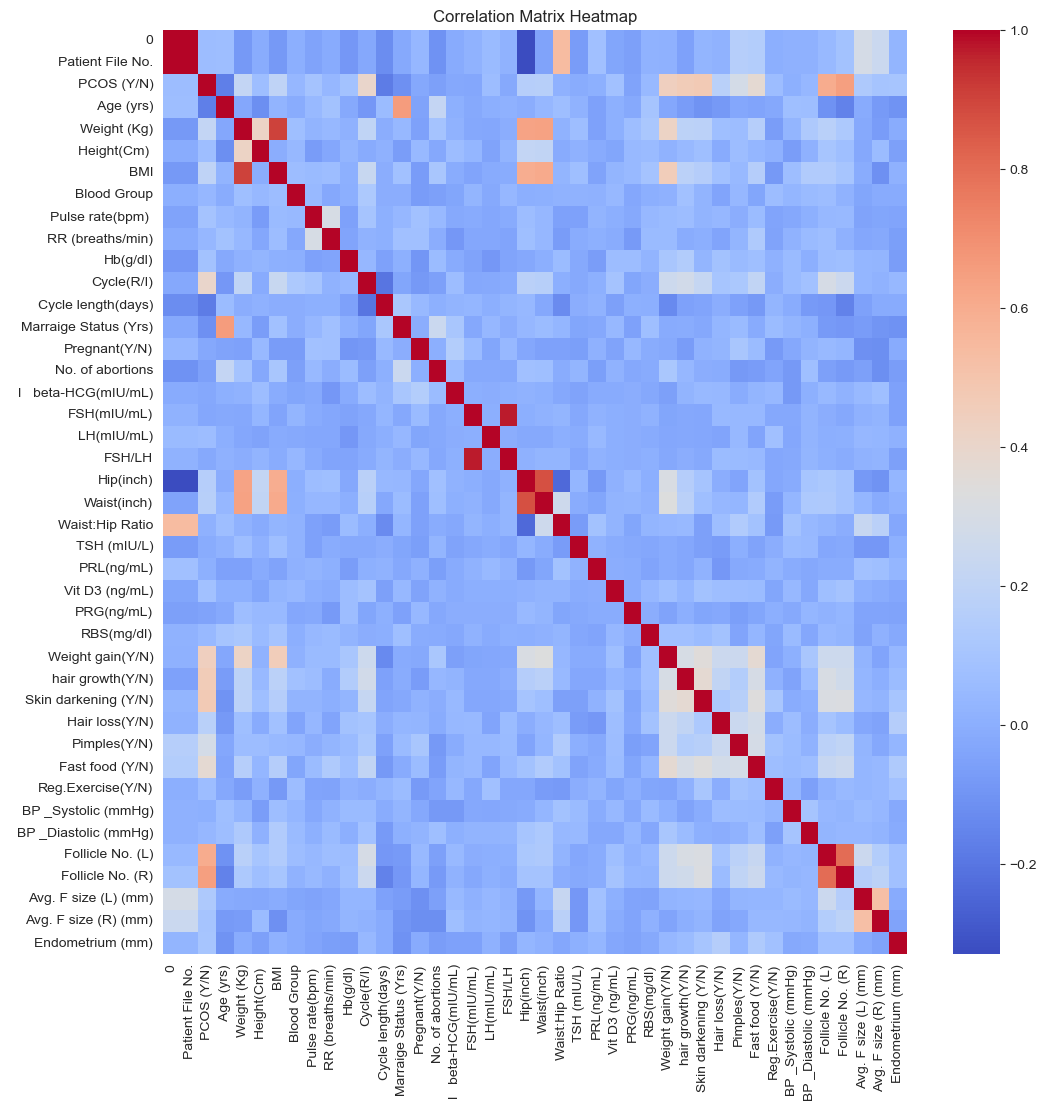

In [52]:
plt.figure(figsize=(12, 12))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False)
plt.title('Correlation Matrix Heatmap')
plt.show()


In [53]:
correlation_with_target = correlation_matrix['PCOS (Y/N)'].sort_values(ascending=False)
print("Correlation of features with PCOS (Y/N):\n", correlation_with_target)


Correlation of features with PCOS (Y/N):
 PCOS (Y/N)                1.000000
Follicle No. (R)          0.648327
Follicle No. (L)          0.603346
Skin darkening (Y/N)      0.475733
hair growth(Y/N)          0.464667
Weight gain(Y/N)          0.441047
Cycle(R/I)                0.401644
Fast food (Y/N)           0.376183
Pimples(Y/N)              0.286077
Weight (Kg)               0.211938
BMI                       0.199697
Hair loss(Y/N)            0.172879
Waist(inch)               0.164598
Hip(inch)                 0.162297
Avg. F size (L) (mm)      0.132992
Endometrium (mm)          0.106648
Avg. F size (R) (mm)      0.097690
Pulse rate(bpm)           0.091821
Hb(g/dl)                  0.087170
Vit D3 (ng/mL)            0.085494
Height(Cm)                0.068254
Reg.Exercise(Y/N)         0.065337
LH(mIU/mL)                0.063879
Patient File No.          0.060998
0                         0.060998
RBS(mg/dl)                0.048922
BP _Diastolic (mmHg)      0.038032
RR (breaths/m

### 5. Selecting Target Variable and Feature Selection using SelectKBest
Here we separate the target column (`PCOS (Y/N)`) and apply feature selection methods like Chi-Square and Mutual Information.


In [54]:
# Separate features (x) and target label (y)
# Column 2 corresponds to PCOS (Y/N) target label in the dataset
columns_to_include = [i for i in range(df.shape[1]) if i != 2]
x = df.iloc[:, columns_to_include].values
y = df.iloc[:, 2].values
print(f"Features shape: {x.shape}, Target labels shape: {y.shape}")


Features shape: (541, 41), Target labels shape: (541,)


#### Chi-Square Feature Selection (k=25)


In [55]:
# k=25 features using Chi-Square test
selector_chi = SelectKBest(chi2, k=25)
X_new_chi = selector_chi.fit_transform(x, y)
print("Chi-Square selected features shape:", X_new_chi.shape)


Chi-Square selected features shape: (541, 25)


#### Mutual Information Feature Selection (k=30 & k=35)


In [56]:
# k=30 features using Mutual Information
selector_mi30 = SelectKBest(mutual_info_classif, k=30)
X_new_mi30 = selector_mi30.fit_transform(x, y)

# k=35 features using Mutual Information
selector_mi35 = SelectKBest(mutual_info_classif, k=35)
X_new_mi35 = selector_mi35.fit_transform(x, y)

print("Mutual Information (k=30) shape:", X_new_mi30.shape)
print("Mutual Information (k=35) shape:", X_new_mi35.shape)


Mutual Information (k=30) shape: (541, 30)
Mutual Information (k=35) shape: (541, 35)


### 6. Experiment 1: Baseline Models (No SMOTE, Standard Features)
In this experiment, standard classifiers are trained on feature-scaled data using **Chi-Square selected features (k=25)**.


In [57]:
# Use the Chi-Square features as default for Baseline experiment
X_train, X_test, y_train, y_test = train_test_split(X_new_chi, y, test_size=0.3, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Classifiers definition
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=500, solver='newton-cg', random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Support Vector Machine': SVC(random_state=42)
}

results_exp1 = {}
for name, clf in classifiers.items():
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)
    
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n--- Confusion Matrix for {name} ---")
    print(cm)
    
    accuracy = accuracy_score(y_test, y_pred)
    results_exp1[name] = accuracy
    print(f'{name} Accuracy : {accuracy * 100:.2f}%')
    print(classification_report(y_test, y_pred, zero_division=0))

# Print summary
print("\nExperiment 1 Results:")
for name, acc in results_exp1.items():
    print(f"{name}: {acc*100:.2f}%")



--- Confusion Matrix for Logistic Regression ---
[[106   4]
 [ 13  40]]
Logistic Regression Accuracy : 89.57%
              precision    recall  f1-score   support

           0       0.89      0.96      0.93       110
           1       0.91      0.75      0.82        53

    accuracy                           0.90       163
   macro avg       0.90      0.86      0.88       163
weighted avg       0.90      0.90      0.89       163


--- Confusion Matrix for Decision Tree ---
[[98 12]
 [14 39]]
Decision Tree Accuracy : 84.05%
              precision    recall  f1-score   support

           0       0.88      0.89      0.88       110
           1       0.76      0.74      0.75        53

    accuracy                           0.84       163
   macro avg       0.82      0.81      0.82       163
weighted avg       0.84      0.84      0.84       163


--- Confusion Matrix for Random Forest ---
[[105   5]
 [ 12  41]]
Random Forest Accuracy : 89.57%
              precision    recall  f1-sco

#### Plotting ROC Curve for Baseline (using the last trained model)


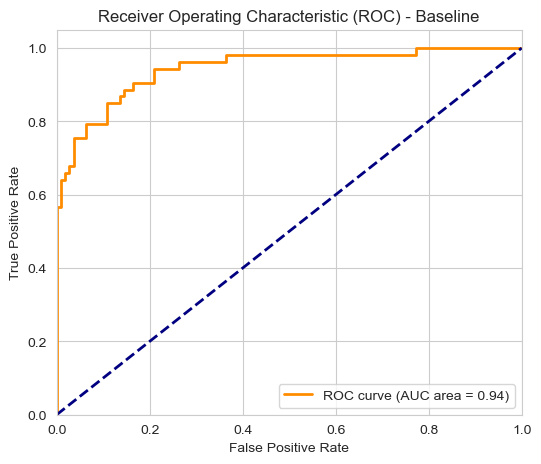

In [58]:
# Calculate ROC curve for SVM (need probability output or decision function)
# Let's train Logistic Regression explicitly to plot ROC
lr_model = LogisticRegression(max_iter=500, solver='newton-cg', random_state=42)
lr_model.fit(X_train_scaled, y_train)
y_pred_prob = lr_model.decision_function(X_test_scaled)

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Baseline')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


### 7. Experiment 2: SMOTE & RFECV (Recursive Feature Elimination)
This experiment balances the dataset with **SMOTE** first, and then runs **RFECV** to recursively eliminate features using **Mutual Information (k=30)** features.


In [59]:
# Split the Mutual Information k=30 features
X_train, X_test, y_train, y_test = train_test_split(X_new_mi30, y, test_size=0.3, random_state=42)

# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Standardize features
scaler = StandardScaler()
X_train_resampled = scaler.fit_transform(X_train_resampled)
X_test = scaler.transform(X_test)

# Classifiers for RFECV (estimating coef_ or feature_importances_)
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=500, solver='newton-cg', random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Support Vector Machine': SVC(kernel='linear', random_state=42) # Requires linear kernel for coef_
}

results_exp2 = {}
for name, clf in classifiers.items():
    rfecv = RFECV(estimator=clf, step=1, cv=5, scoring='accuracy')
    rfecv.fit(X_train_resampled, y_train_resampled)
    
    # Transform datasets based on selected features by RFECV
    X_train_rfecv = rfecv.transform(X_train_resampled)
    X_test_rfecv = rfecv.transform(X_test)
    
    # Re-fit and predict
    clf.fit(X_train_rfecv, y_train_resampled)
    y_pred = clf.predict(X_test_rfecv)
    
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n--- Confusion Matrix for {name} with RFECV (Features kept: {rfecv.n_features_}) ---")
    print(cm)
    
    accuracy = accuracy_score(y_test, y_pred)
    results_exp2[name] = accuracy
    print(f'{name} Accuracy: {accuracy * 100:.2f}%')
    print(classification_report(y_test, y_pred, zero_division=0))

# Print summary
print("\nExperiment 2 Results (SMOTE + RFECV):")
for name, acc in results_exp2.items():
    print(f"{name}: {acc*100:.2f}%")



--- Confusion Matrix for Logistic Regression with RFECV (Features kept: 10) ---
[[101   9]
 [  8  45]]
Logistic Regression Accuracy: 89.57%
              precision    recall  f1-score   support

           0       0.93      0.92      0.92       110
           1       0.83      0.85      0.84        53

    accuracy                           0.90       163
   macro avg       0.88      0.88      0.88       163
weighted avg       0.90      0.90      0.90       163


--- Confusion Matrix for Decision Tree with RFECV (Features kept: 20) ---
[[100  10]
 [ 17  36]]
Decision Tree Accuracy: 83.44%
              precision    recall  f1-score   support

           0       0.85      0.91      0.88       110
           1       0.78      0.68      0.73        53

    accuracy                           0.83       163
   macro avg       0.82      0.79      0.80       163
weighted avg       0.83      0.83      0.83       163


--- Confusion Matrix for Random Forest with RFECV (Features kept: 25) ---
[

#### Plotting ROC Curve for Experiment 2 (Logistic Regression + RFECV)


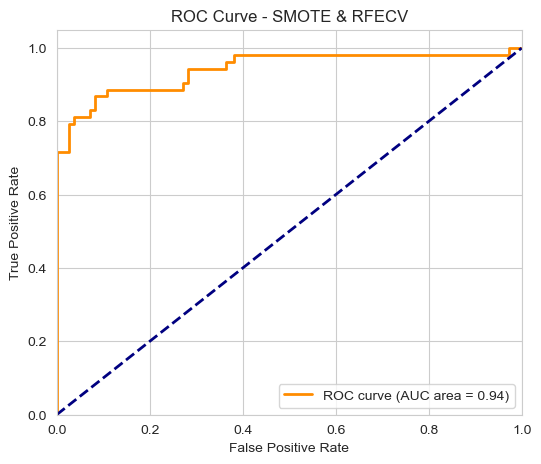

In [60]:
# Using the last model (SVC linear) for ROC curve
# Since SVC kernel is linear, we can use decision_function
# y_pred_decision = classifiers['Logistic Regression'].predict_proba(X_test_rfecv)[:, 1] if hasattr(classifiers['Logistic Regression'], 'predict_proba') else classifiers['Logistic Regression'].decision_function(X_test_rfecv) 

# Re-extract the correct feature columns selected for Logistic Regression
lr_rfecv = RFECV(estimator=LogisticRegression(max_iter=500, solver='newton-cg', random_state=42), step=1, cv=5, scoring='accuracy').fit(X_train_resampled, y_train_resampled)
y_pred_decision = classifiers['Logistic Regression'].predict_proba(lr_rfecv.transform(X_test))[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_decision)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SMOTE & RFECV')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


### 8. Experiment 3: GridSearchCV (Hyperparameter Tuning for Standard Classifiers)
Tuning hyper-parameters using **GridSearchCV** on balanced standard models (SMOTE, scaling) using **Mutual Information (k=35)** features.


In [61]:
# Use Mutual Information k=35 features
X_train, X_test, y_train, y_test = train_test_split(X_new_mi35, y, test_size=0.3, random_state=42)

# Apply SMOTE to training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Standardize
scaler = StandardScaler()
X_train_resampled = scaler.fit_transform(X_train_resampled)
X_test = scaler.transform(X_test)

# Classifiers and parameter grids
classifiers = {
    'Logistic Regression': (LogisticRegression(max_iter=500, solver='newton-cg', random_state=42), {
        'C': [0.01, 0.1, 1, 10, 100]
    }),
    'Decision Tree': (DecisionTreeClassifier(random_state=42), {
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10]
    }),
    'Random Forest': (RandomForestClassifier(random_state=42), {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10]
    }),
    'Support Vector Machine': (SVC(kernel='linear', random_state=42), {
        'C': [0.01, 0.1, 1, 10, 100]
    }),
    'K-Nearest Neighbors': (KNeighborsClassifier(), {
        'n_neighbors': [3, 5, 7, 9],
        'weights': ['uniform', 'distance']
    }),
    'Naive Bayes': (GaussianNB(), {})
}

results_exp3 = {}
for name, (clf, param_grid) in classifiers.items():
    # Perform Grid Search
    grid_search = GridSearchCV(estimator=clf, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
    grid_search.fit(X_train_resampled, y_train_resampled)
    
    print(f"\nBest parameters for {name}: {grid_search.best_params_}")
    
    best_clf = grid_search.best_estimator_
    y_pred = best_clf.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred)
    print(f"Confusion Matrix for {name}:\n", cm)
    
    accuracy = accuracy_score(y_test, y_pred)
    results_exp3[name] = accuracy
    print(f'{name} Accuracy: {accuracy * 100:.2f}%')
    print(classification_report(y_test, y_pred, zero_division=0))

# Print summary
print("\nExperiment 3 Results (GridSearchCV with MI k=35):")
for name, acc in results_exp3.items():
    print(f"{name}: {acc*100:.2f}%")


Fitting 3 folds for each of 5 candidates, totalling 15 fits

Best parameters for Logistic Regression: {'C': 0.01}
Confusion Matrix for Logistic Regression:
 [[103   7]
 [ 12  41]]
Logistic Regression Accuracy: 88.34%
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       110
           1       0.85      0.77      0.81        53

    accuracy                           0.88       163
   macro avg       0.87      0.85      0.86       163
weighted avg       0.88      0.88      0.88       163

Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best parameters for Decision Tree: {'max_depth': None, 'min_samples_split': 5}
Confusion Matrix for Decision Tree:
 [[95 15]
 [13 40]]
Decision Tree Accuracy: 82.82%
              precision    recall  f1-score   support

           0       0.88      0.86      0.87       110
           1       0.73      0.75      0.74        53

    accuracy                           0.83       163
   macro a

### 9. Experiment 4: Advanced Ensemble Models (GridSearchCV on Full Feature Set)
In this experiment, we run GridSearch on ensemble and boosting methods (XGBoost, CatBoost, AdaBoost, Bagging) using **all raw features** (no `SelectKBest` pre-filtering).


In [62]:
# Split the full raw feature matrix (x) and target labels (y)
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Standardize features
scaler = StandardScaler()
X_train_resampled = scaler.fit_transform(X_train_resampled)
X_test = scaler.transform(X_test)

# Classifiers and parameter grids
# 'estimator' parameter is used instead of deprecated 'base_estimator' for modern scikit-learn compatibility
classifiers = {
    'Decision Tree': (DecisionTreeClassifier(random_state=42), {
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10]
    }),
    'Random Forest': (RandomForestClassifier(random_state=42), {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10]
    }),
    'Bagging with AdaBoost': (BaggingClassifier(estimator=AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), random_state=42), random_state=42), {
        'max_samples': [0.5, 1.0],
        'max_features': [0.5, 1.0],
        'estimator__estimator__max_depth': [1, 2, 3] # Nested estimator param path
    }),
    'XGBoost': (xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'), {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7],
    }),
    'CatBoost': (CatBoostClassifier(random_state=42, verbose=0), {
        'iterations': [100, 200, 300],
        'depth': [3, 5, 7]
    })
}

results_exp4 = {}
for name, (clf, param_grid) in classifiers.items():
    grid_search = GridSearchCV(estimator=clf, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
    grid_search.fit(X_train_resampled, y_train_resampled)
    
    print(f"\nBest parameters for {name}: {grid_search.best_params_}")
    
    best_clf = grid_search.best_estimator_
    y_pred = best_clf.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred)
    print(f"Confusion Matrix for {name}:\n", cm)
    
    accuracy = accuracy_score(y_test, y_pred)
    results_exp4[name] = accuracy
    print(f'{name} Accuracy: {accuracy * 100:.2f}%')
    print(classification_report(y_test, y_pred, zero_division=0))

# Print summary
print("\nExperiment 4 Results (Ensembles on all features):")
for name, acc in results_exp4.items():
    print(f"{name}: {acc*100:.2f}%")


Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best parameters for Decision Tree: {'max_depth': None, 'min_samples_split': 2}
Confusion Matrix for Decision Tree:
 [[96 14]
 [12 41]]
Decision Tree Accuracy: 84.05%
              precision    recall  f1-score   support

           0       0.89      0.87      0.88       110
           1       0.75      0.77      0.76        53

    accuracy                           0.84       163
   macro avg       0.82      0.82      0.82       163
weighted avg       0.84      0.84      0.84       163

Fitting 3 folds for each of 36 candidates, totalling 108 fits

Best parameters for Random Forest: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 300}
Confusion Matrix for Random Forest:
 [[106   4]
 [  9  44]]
Random Forest Accuracy: 92.02%
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       110
           1       0.92      0.83      0.87        53

    accuracy                 

/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/ana


Best parameters for Bagging with AdaBoost: {'estimator__estimator__max_depth': 3, 'max_features': 1.0, 'max_samples': 1.0}
Confusion Matrix for Bagging with AdaBoost:
 [[101   9]
 [  8  45]]
Bagging with AdaBoost Accuracy: 89.57%
              precision    recall  f1-score   support

           0       0.93      0.92      0.92       110
           1       0.83      0.85      0.84        53

    accuracy                           0.90       163
   macro avg       0.88      0.88      0.88       163
weighted avg       0.90      0.90      0.90       163

Fitting 3 folds for each of 27 candidates, totalling 81 fits


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [15:45:05] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [15:45:05] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [15:45:05] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [15:45:05] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i


Best parameters for XGBoost: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Confusion Matrix for XGBoost:
 [[105   5]
 [ 11  42]]
XGBoost Accuracy: 90.18%
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       110
           1       0.89      0.79      0.84        53

    accuracy                           0.90       163
   macro avg       0.90      0.87      0.88       163
weighted avg       0.90      0.90      0.90       163

Fitting 3 folds for each of 9 candidates, totalling 27 fits

Best parameters for CatBoost: {'depth': 7, 'iterations': 300}
Confusion Matrix for CatBoost:
 [[104   6]
 [ 11  42]]
CatBoost Accuracy: 89.57%
              precision    recall  f1-score   support

           0       0.90      0.95      0.92       110
           1       0.88      0.79      0.83        53

    accuracy                           0.90       163
   macro avg       0.89      0.87      0.88       163
weighted avg       0.89     

### 10. Performance Visualizations
These plots (from `Charts.ipynb`) trace the relationship between the number of selected features (k) and model accuracy across different selection metrics (ANOVA, Chi-Square, and Mutual Information).


#### Visualizing Accuracy vs. Number of Features (ANOVA, Chi-Square, Mutual Info)


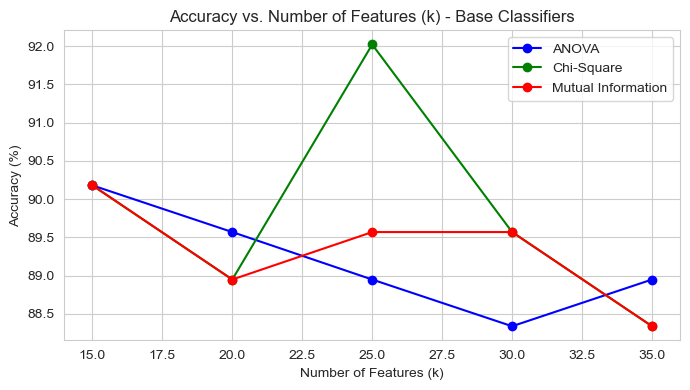

In [63]:
# Data for the feature count sensitivity plots
k_values = [15, 20, 25, 30, 35]
accuracy_anova = [90.18, 89.57, 88.95, 88.34, 88.95]
accuracy_chi2 = [90.18, 88.95, 92.02, 89.57, 88.34]
accuracy_mutual_info = [90.18, 88.95, 89.57, 89.57, 88.34]

plt.figure(figsize=(7, 4))
plt.plot(k_values, accuracy_anova, label='ANOVA', color='blue', marker='o')
plt.plot(k_values, accuracy_chi2, label='Chi-Square', color='green', marker='o')
plt.plot(k_values, accuracy_mutual_info, label='Mutual Information', color='red', marker='o')

plt.title('Accuracy vs. Number of Features (k) - Base Classifiers')
plt.xlabel('Number of Features (k)')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


#### Visualizing Accuracy vs. Number of Features (SMOTE + RFECV / Tuning experiments)


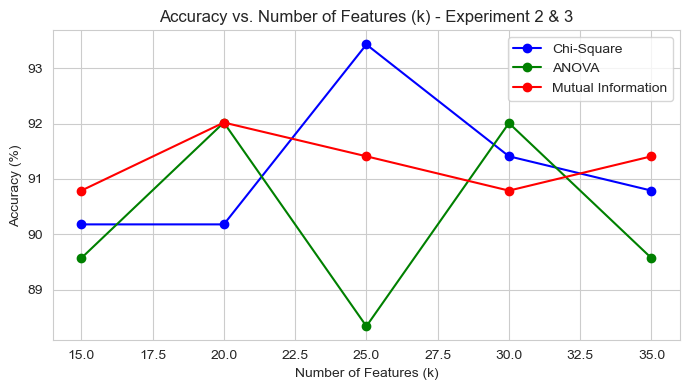

In [64]:
accuracy_chi2_exp2 = [90.18, 90.18, 93.43, 91.41, 90.79]
accuracy_anova_exp2 = [89.57, 92.02, 88.34, 92.01, 89.57]
accuracy_mutual_info_exp2 = [90.79, 92.02, 91.41, 90.79, 91.41]

plt.figure(figsize=(7, 4))
plt.plot(k_values, accuracy_chi2_exp2, label='Chi-Square', color='blue', marker='o')
plt.plot(k_values, accuracy_anova_exp2, label='ANOVA', color='green', marker='o')
plt.plot(k_values, accuracy_mutual_info_exp2, label='Mutual Information', color='red', marker='o')

plt.title('Accuracy vs. Number of Features (k) - Experiment 2 & 3')
plt.xlabel('Number of Features (k)')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


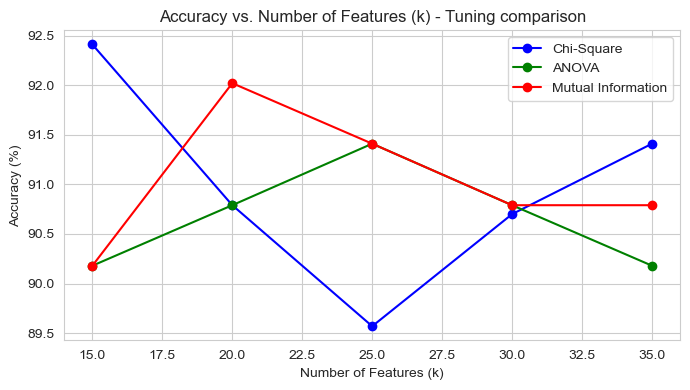

In [65]:
accuracy_chi2_exp4 = [92.41, 90.79, 89.57, 90.7, 91.41]
accuracy_anova_exp4 = [90.18, 90.79, 91.41, 90.79, 90.18]
accuracy_mutual_info_exp4 = [90.18, 92.02, 91.41, 90.79, 90.79]

plt.figure(figsize=(7, 4))
plt.plot(k_values, accuracy_chi2_exp4, label='Chi-Square', color='blue', marker='o')
plt.plot(k_values, accuracy_anova_exp4, label='ANOVA', color='green', marker='o')
plt.plot(k_values, accuracy_mutual_info_exp4, label='Mutual Information', color='red', marker='o')

plt.title('Accuracy vs. Number of Features (k) - Tuning comparison')
plt.xlabel('Number of Features (k)')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
